# AppVision Analytics · Launch Readiness Study
## 03 · Launch Outlook model

**Brief questions answered here:**
- *Which of our three concepts has the best realistic odds?*
- *What install number should year one be planned around?*

**Approach:** Trained a model that sees only what a studio knows **before launch** and outputs the chance of landing in each of five install bands. Tested it on apps from **developers it never saw during training**, and compared it with two simple baselines it has to beat to be worth using.

**Inputs:** category, age rating, price, ads, in-app purchases, download size, minimum Android version, whether a website and privacy policy are listed, the studio's earlier apps, the wording of the app name, and time on the store (the horizon the studio picks). Ratings, reviews, Editors' Choice and update history are deliberately excluded: they only exist after launch, and in v1 they leaked the answer (notebook 02).

In [1]:
import gc
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from appvision import bands, features, names
from appvision.client import CONCEPTS
from appvision.outlook import LaunchOutlook, per_hundred, one_in, median_band
from appvision.style import use_notebook_style, BLUE, ORANGE, INK_2, MUTED, AXIS, BAND_COLORS

use_notebook_style()
ARTIFACTS = REPO / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
SEED = 42

### 1 · Chose who the model learns from
Kept apps with a valid release date that had been live between **30 days and 6 years** at the June 2021 scrape. Apps younger than a month haven't had time to show anything. Apps older than six years launched into a much emptier store and say little about launching today. Time on the store stays in the model as an input, so a studio can ask for its outlook after 6 months, 1 year, 2 years or 3 years.

In [2]:
cols = ["app_name", "developer_id", "category", "content_rating", "free", "price_usd", "ad_supported",
        "in_app_purchases", "size_mb", "size_varies", "min_android", "min_android_varies", "has_website",
        "has_privacy", "dev_prior_apps", "dev_prior_log_installs", "name_words", "age_days", "installs", "band", "in_model"]
all_apps = pd.read_parquet(REPO / "data" / "v2" / "apps_2021.parquet", columns=["installs", "band"])
store_stats = {
    "apps": int(len(all_apps)),
    "band_shares": all_apps["band"].value_counts(normalize=True).sort_index().round(4).tolist(),
    "median_installs": float(all_apps["installs"].median()),
    "share_breakout": float((all_apps["installs"] >= bands.BREAKOUT_MIN).mean()),
}
del all_apps

df = pd.read_parquet(REPO / "data" / "v2" / "apps_2021.parquet", columns=cols)
df = df[(df["in_model"] == 1) & df["age_days"].between(30, 2200)].drop(columns="in_model").reset_index(drop=True)
dev = pd.factorize(df.pop("developer_id"))[0]
y = df["band"].to_numpy()
y_log = np.log10(df["installs"].to_numpy() + 1)
print(f"Modelling set: {len(df):,} apps from {dev.max() + 1:,} developers")

Modelling set: 2,015,329 apps from 682,251 developers


### 2 · Split by developer, not by app
14% of apps come from developers with more than 100 apps, often near-identical templates. A random split would put one developer's templates on both sides and flatter the model. Held out **20% of developers** for the final test, and a further 10% of training developers for early stopping.

In [3]:
tr, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=SEED).split(df, groups=dev))
fit_pos, val_pos = next(GroupShuffleSplit(1, test_size=0.1, random_state=7).split(tr, groups=dev[tr]))
fit, val = tr[fit_pos], tr[val_pos]
print(f"Train: {len(fit):,} apps · early-stopping set: {len(val):,} · test: {len(te):,} apps from "
      f"{len(np.unique(dev[te])):,} unseen developers")

Train: 1,454,082 apps · early-stopping set: 163,812 · test: 397,435 apps from 136,451 unseen developers


### 3 · Turned app names into a signal
Names carry real information. "VPN", "launcher" and "photo editor" live in very different markets from "wallpaper", "theme" or one novel per app. Encoded each name as hashed word and word-pair counts (TF-IDF) and fitted a ridge regression on log installs. The model sees the regression's output as one number, the **name signal**.

To keep this honest, the signal for each training app came from a model fitted on *other developers' apps* (5-fold, grouped by developer). Test apps were scored by a model that never saw their developer.

In [4]:
counts = names.hashed_counts(df.pop("app_name").to_numpy())
idf = names.fit_idf(counts[tr])
Xt = names.tfidf(counts, idf)
del counts

ALPHA = 3.0
signal = np.zeros(len(df), dtype=np.float32)
for a, b in GroupKFold(5).split(tr, groups=dev[tr]):
    ridge = Ridge(alpha=ALPHA, solver="sparse_cg", max_iter=300, tol=1e-3).fit(Xt[tr[a]], y_log[tr[a]])
    signal[tr[b]] = ridge.predict(Xt[tr[b]])
name_model = Ridge(alpha=ALPHA, solver="sparse_cg", max_iter=300, tol=1e-3).fit(Xt[tr], y_log[tr])
signal[te] = name_model.predict(Xt[te])
df["name_signal"] = signal
del Xt
gc.collect()

def r2(a, b):
    return 1 - ((a - b) ** 2).sum() / ((a - a.mean()) ** 2).sum()

print(f"Name signal alone explains {r2(y_log[te], signal[te]):.1%} of the variation in log installs on unseen developers")

Name signal alone explains 20.5% of the variation in log installs on unseen developers


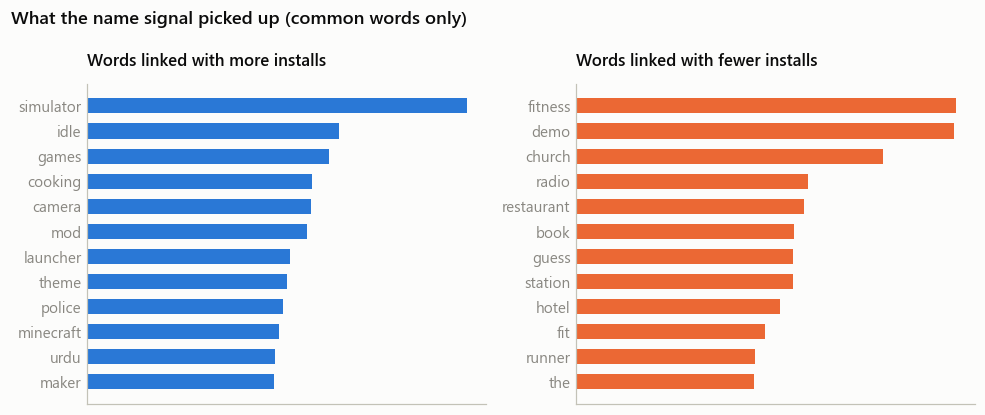

In [5]:
# Read the hashed coefficients back for common words, to see what the signal learned
sample_names = pd.read_parquet(REPO / "data" / "v2" / "apps_2021.parquet", columns=["app_name"])["app_name"] \
    .sample(400_000, random_state=1).astype(str).str.lower()
words = sample_names.str.findall(r"(?u)\b\w\w+\b").explode().value_counts()
ascii_word = words.index.map(lambda w: w.isascii() and not w.isdigit()).to_numpy(dtype=bool)
words = words[(words.to_numpy() >= 400) & ascii_word]
idx = names.hashed_counts(list(words.index)).indices
word_effect = pd.Series(name_model.coef_[idx], index=words.index)
top_up = word_effect.sort_values(ascending=False).head(12)
top_down = word_effect.sort_values().head(12)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=False)
for ax, s, color, title in [(axes[0], top_up[::-1], BLUE, "Words linked with more installs"),
                            (axes[1], top_down[::-1].abs(), ORANGE, "Words linked with fewer installs")]:
    ax.barh(s.index, s.values, color=color, height=0.6)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", visible=False)
    ax.set_xticks([])
fig.suptitle("What the name signal picked up (common words only)", x=0.01, ha="left", fontweight="semibold")
plt.tight_layout()
plt.show()

### 4 · Set the bar: two baselines the model must beat
- **Always guess "under 1K":** right more than half the time, because most apps really do stay there. It shows why raw accuracy flatters any model here.
- **Category and age only:** for each category and time-on-store band, use the mix of outcomes seen in training. This is what a studio could get by just looking up its category.

In [6]:
def _norm(p):
    p = np.clip(p, 1e-7, 1)
    return p / p.sum(1, keepdims=True)

def evaluate(p, yt):
    pred = p.argmax(1)
    odds = bands.reach_odds(p)
    return {
        "accuracy": accuracy_score(yt, pred),
        "within_one": float((np.abs(pred - yt) <= 1).mean()),
        "macro_f1": f1_score(yt, pred, average="macro"),
        "log_loss": log_loss(yt, _norm(p), labels=range(5)),
        **{f"auc_{t}": roc_auc_score(yt >= k + 1, odds[:, k]) for k, t in enumerate(["1k", "10k", "100k", "1m"])},
    }

yt = y[te]
p_major = np.tile(np.bincount(y[tr], minlength=5) / len(tr), (len(te), 1))
base_major = evaluate(p_major, yt)
for k in ["auc_1k", "auc_10k", "auc_100k", "auc_1m"]:
    base_major[k] = 0.5

AGE_EDGES = [0, 182, 365, 730, 1095, 1825, 100_000]
age_idx = np.clip(np.searchsorted(AGE_EDGES, df["age_days"].to_numpy(), side="right") - 1, 0, len(AGE_EDGES) - 2)
cat = df["category"].astype(str).to_numpy()
key = pd.Series(cat + "|" + age_idx.astype(str))
rates = pd.crosstab(key.iloc[tr], y[tr], normalize="index").reindex(columns=range(5), fill_value=0)
p_cat = rates.reindex(key.iloc[te]).fillna(1 / 5).to_numpy()
base_cat = evaluate(p_cat, yt)

pd.DataFrame({"always 'under 1K'": base_major, "category + age": base_cat}).T.style.format("{:.3f}")

,accuracy,within_one,macro_f1,log_loss,auc_1k,auc_10k,auc_100k,auc_1m
always 'under 1K',0.568,0.802,0.145,1.142,0.500,0.500,0.500,0.500
category + age,0.569,0.816,0.188,1.070,0.683,0.706,0.754,0.810


### 5 · Trained the model, adding one kind of information at a time
Used XGBoost (gradient-boosted trees) with five-way softmax output and native categorical handling, with early stopping on the held-out developers. To see what each kind of information adds, fitted four versions on the same 600K-app training sample:
1. product setup only
2. plus the studio's track record
3. plus the name wording instead of track record
4. everything

Then fitted the final model with every feature on the full training set.

In [7]:
X = features.to_model_frame(df)
PARAMS = dict(objective="multi:softprob", num_class=5, tree_method="hist", max_depth=8, eta=0.1, subsample=0.8,
              colsample_bytree=0.8, min_child_weight=50, max_cat_to_onehot=1, max_bin=128,
              eval_metric="mlogloss", nthread=8, seed=0)

def train(feats, rows):
    dtr = xgb.QuantileDMatrix(X.iloc[rows][feats], label=y[rows], enable_categorical=True, max_bin=128)
    dva = xgb.QuantileDMatrix(X.iloc[val][feats], label=y[val], enable_categorical=True, ref=dtr, max_bin=128)
    bst = xgb.train(PARAMS, dtr, 3000, evals=[(dva, "val")], early_stopping_rounds=50, verbose_eval=False)
    p = bst.predict(xgb.DMatrix(X.iloc[te][feats], enable_categorical=True), iteration_range=(0, bst.best_iteration + 1))
    return bst, p

ALL = features.FEATURES
NO_DEV = [f for f in ALL if not f.startswith("dev_")]
NO_NAME = [f for f in ALL if f not in ("name_signal", "name_words")]
PRODUCT = [f for f in NO_DEV if f not in ("name_signal", "name_words")]

rng = np.random.default_rng(0)
sub = np.sort(rng.choice(fit, size=600_000, replace=False))
ablation = {}
for label, feats in [("Product setup only", PRODUCT), ("+ studio track record", NO_NAME),
                     ("+ name wording (no track record)", NO_DEV), ("Everything", ALL)]:
    _, p = train(feats, sub)
    ablation[label] = evaluate(p, yt)
    print(f"{label:<34} AUC 10K+ {ablation[label]['auc_10k']:.3f} · accuracy {ablation[label]['accuracy']:.3f}")

Product setup only                 AUC 10K+ 0.796 · accuracy 0.585


+ studio track record              AUC 10K+ 0.868 · accuracy 0.636


+ name wording (no track record)   AUC 10K+ 0.835 · accuracy 0.607


Everything                         AUC 10K+ 0.884 · accuracy 0.647


In [8]:
booster, p_model = train(ALL, fit)
model_metrics = evaluate(p_model, yt)
print(f"Final model: {booster.best_iteration + 1} trees per band")

comparison = pd.DataFrame({"always 'under 1K'": base_major, "category + age": base_cat, "Launch Outlook model": model_metrics}).T
comparison = comparison.rename(columns={"accuracy": "exact band", "within_one": "within one band", "macro_f1": "macro F1",
                                        "log_loss": "log loss (lower is better)", "auc_1k": "AUC 1K+", "auc_10k": "AUC 10K+",
                                        "auc_100k": "AUC 100K+", "auc_1m": "AUC 1M+"})
comparison.style.format("{:.3f}")

Final model: 338 trees per band


,exact band,within one band,macro F1,log loss (lower is better),AUC 1K+,AUC 10K+,AUC 100K+,AUC 1M+
always 'under 1K',0.568,0.802,0.145,1.142,0.500,0.500,0.500,0.500
category + age,0.569,0.816,0.188,1.070,0.683,0.706,0.754,0.810
Launch Outlook model,0.647,0.927,0.457,0.825,0.859,0.885,0.926,0.964


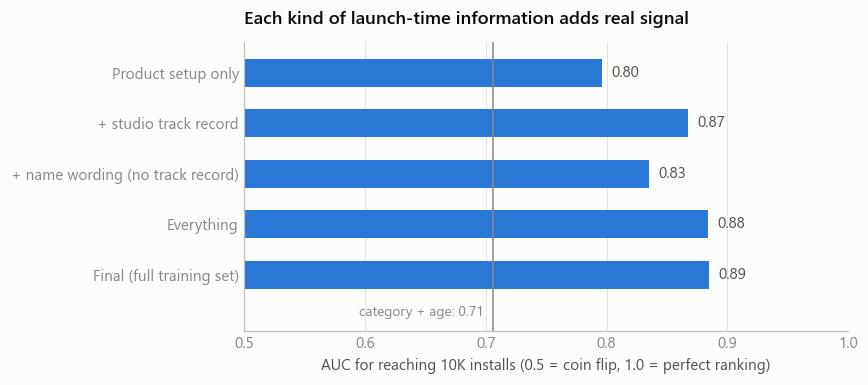

In [9]:
labels = list(ablation) + ["Final (full training set)"]
auc10 = [ablation[k]["auc_10k"] for k in ablation] + [model_metrics["auc_10k"]]
fig, ax = plt.subplots(figsize=(8, 3.6))
yy = np.arange(len(labels))[::-1]
ax.barh(yy, auc10, color=[BLUE] * len(labels), height=0.55)
for yi, v in zip(yy, auc10):
    ax.annotate(f"{v:.2f}", (v, yi), xytext=(6, 0), textcoords="offset points", va="center", color=INK_2)
ax.axvline(base_cat["auc_10k"], color=MUTED, linewidth=1)
ax.annotate(f"category + age: {base_cat['auc_10k']:.2f}", (base_cat["auc_10k"], -0.75), xytext=(-6, 0),
            textcoords="offset points", ha="right", va="center", color=MUTED, fontsize=9)
ax.set_ylim(-1.1, len(labels) - 0.4)
ax.set_xlim(0.5, 1.0)
ax.set_yticks(yy, labels)
ax.set_xlabel("AUC for reaching 10K installs (0.5 = coin flip, 1.0 = perfect ranking)")
ax.set_title("Each kind of launch-time information adds real signal")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 6 · Checked that the odds mean what they say
A forecast like "30% chance" is only useful if about 30% of such apps really get there. Grouped test apps by their predicted chance of passing 10K installs and compared that with what happened.

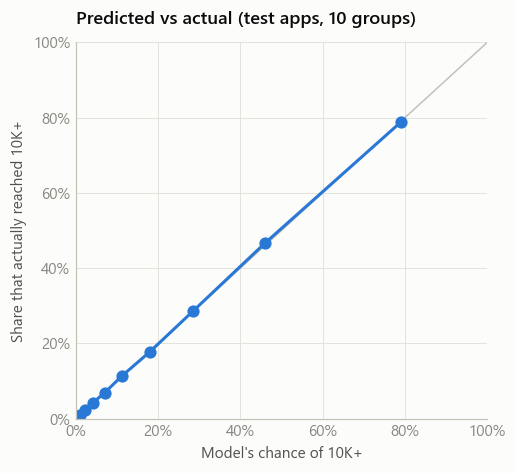

Largest gap between predicted and actual across the 10 groups: 0.7%


In [10]:
odds_te = bands.reach_odds(p_model)
pred10, real10 = odds_te[:, 1], (yt >= 2)
bins = np.quantile(pred10, np.linspace(0, 1, 11))
which = np.clip(np.searchsorted(bins, pred10, side="right") - 1, 0, 9)
calib = pd.DataFrame({"predicted": pred10, "observed": real10, "bin": which}).groupby("bin").agg(
    predicted=("predicted", "mean"), observed=("observed", "mean"), apps=("observed", "size"))

fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1)
ax.plot(calib["predicted"], calib["observed"], color=BLUE, marker="o", markersize=7)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Model's chance of 10K+")
ax.set_ylabel("Share that actually reached 10K+")
ax.set_title("Predicted vs actual (test apps, 10 groups)")
plt.tight_layout()
plt.show()
print(f"Largest gap between predicted and actual across the 10 groups: {(calib['predicted'] - calib['observed']).abs().max():.1%}")

### 7 · What drives the outlook

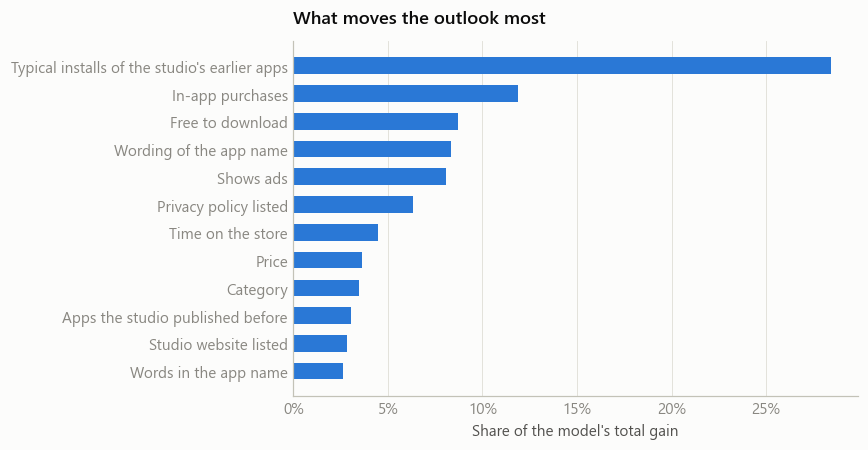

In [11]:
gain = booster.get_score(importance_type="gain")
importance = (pd.Series(gain).rename(index=features.FEATURE_LABELS) / sum(gain.values())).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.2))
top = importance.head(12)[::-1]
ax.barh(top.index, top.values, color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlabel("Share of the model's total gain")
ax.set_title("What moves the outlook most")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 8 · Saved the model and everything the app shows
Saved the trees in XGBoost's portable format and the name weights as plain arrays, with no pickles. Every metric the app displays is written to `outlook_meta.json` here, so none is ever typed in by hand.

In [12]:
booster.save_model(ARTIFACTS / "outlook_model.ubj")
np.save(ARTIFACTS / "name_idf.npy", idf.astype(np.float32))
np.save(ARTIFACTS / "name_coef.npy", name_model.coef_.astype(np.float32))

base_rates = {"age_edges": AGE_EDGES, "by_category": {}}
for c in features.CATEGORIES:
    rows_c = []
    for a in range(len(AGE_EDGES) - 1):
        k = f"{c}|{a}"
        rows_c.append([round(float(v), 4) for v in (rates.loc[k] if k in rates.index else np.full(5, np.nan))])
    base_rates["by_category"][c] = rows_c
overall = pd.crosstab(age_idx[tr], y[tr], normalize="index").reindex(columns=range(5), fill_value=0)
base_rates["by_category"]["__all__"] = [[round(float(v), 4) for v in overall.loc[a]] for a in range(len(AGE_EDGES) - 1)]
for c, rows_c in base_rates["by_category"].items():
    base_rates["by_category"][c] = [r if not np.isnan(r).any() else base_rates["by_category"]["__all__"][i]
                                    for i, r in enumerate(rows_c)]

def clean(d):
    return {k: round(float(v), 4) for k, v in d.items()}

meta = {
    "data_snapshot": "2021-06-16",
    "features": features.FEATURES,
    "name_model": {"intercept": float(name_model.intercept_), "alpha": ALPHA, "r2_test": round(r2(y_log[te], signal[te]), 4)},
    "metrics": {
        "train_apps": int(len(fit)), "test_apps": int(len(te)), "test_developers": int(len(np.unique(dev[te]))),
        "model": clean(model_metrics), "baseline_category_age": clean(base_cat), "baseline_majority": clean(base_major),
        "ablation": {k: clean(v) for k, v in ablation.items()},
        "calibration_10k": [[round(float(r.predicted), 4), round(float(r.observed), 4), int(r.apps)] for r in calib.itertuples()],
    },
    "base_rates": base_rates,
    "store_stats": store_stats,
    "importance": [{"label": k, "share": round(float(v), 4)} for k, v in importance.items()],
}
(ARTIFACTS / "outlook_meta.json").write_text(json.dumps(meta, indent=1), encoding="utf-8")
for f in ["outlook_model.ubj", "outlook_meta.json", "name_idf.npy", "name_coef.npy"]:
    print(f"{f:<20} {(ARTIFACTS / f).stat().st_size / 1e6:6.1f} MB")

outlook_model.ubj      22.2 MB
outlook_meta.json       0.0 MB
name_idf.npy            4.2 MB
name_coef.npy           4.2 MB


### 9 · The answer for Osu Lane Studio
Scored the three concepts exactly as the app does, by reloading the saved files, with the studio's real situation: two earlier apps that each reached 1K–10K installs, a website and a privacy policy. Horizon: one year on the store.

In [13]:
outlook = LaunchOutlook(ARTIFACTS)
keys = list(CONCEPTS)
probs = outlook.band_probs([CONCEPTS[k] for k in keys])
odds = bands.reach_odds(probs)
answer = pd.DataFrame({
    "concept": [f"{k} · {CONCEPTS[k].title}" for k in keys],
    "category": [CONCEPTS[k].category for k in keys],
    "typical outcome after 1 year": [bands.BAND_LABELS[median_band(p)] for p in probs],
    "chance of 1K+": odds[:, 0], "chance of 10K+": odds[:, 1], "chance of 100K+": odds[:, 2],
    "typical app in the category, 10K+": [bands.reach_odds(outlook.typical(CONCEPTS[k].category, 365))[0][1] for k in keys],
}).set_index("concept")
answer.style.format({c: "{:.0%}" for c in answer.columns if c.startswith(("chance", "typical app"))})

,category,typical outcome after 1 year,chance of 1K+,chance of 10K+,chance of 100K+,"typical app in the category, 10K+"
concept,,,,,,
A · Budget and expense tracker,Finance,1K–10K,51%,16%,2%,17%
B · Offline word puzzle game,Word,1K–10K,74%,32%,9%,22%
C · Exam prep flashcards quiz,Education,Under 1K,48%,9%,1%,10%


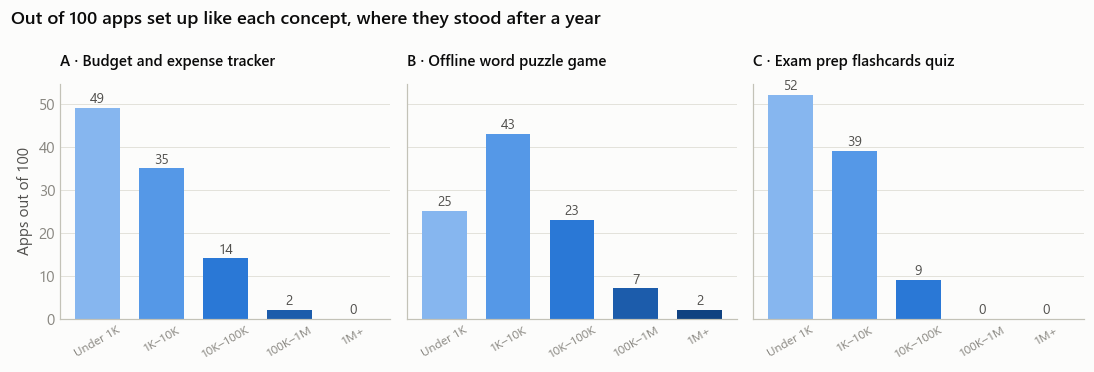

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
for ax, k, p in zip(axes, keys, probs):
    n = per_hundred(p)
    ax.bar(bands.BAND_LABELS, n, color=BAND_COLORS, width=0.7)
    for xi, v in enumerate(n):
        ax.annotate(str(v), (xi, v), xytext=(0, 3), textcoords="offset points", ha="center", color=INK_2, fontsize=9)
    ax.set_title(f"{k} · {CONCEPTS[k].title}", fontsize=10)
    ax.tick_params(axis="x", labelsize=8, rotation=30)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Apps out of 100")
fig.suptitle("Out of 100 apps set up like each concept, where they stood after a year", x=0.01, ha="left",
             fontweight="semibold")
plt.tight_layout()
plt.show()

In [15]:
best = keys[int(np.argmax(odds[:, 1]))]
print(f"What-if for concept {best} (chance of 10K+ after one year):")
for row in outlook.what_if(CONCEPTS[best]):
    print(f"  {row['change']:<32} {row['before'][1]:.0%} → {row['after'][1]:.0%}")

What-if for concept B (chance of 10K+ after one year):


  Charge $2.99 up front            32% → 12%
  Remove ads                       32% → 27%
  Remove in-app purchases          32% → 23%
  Cut the download to 22 MB        32% → 28%


### Takeaways for the studio
- **Concept B (offline word puzzle) is the strongest bet.** Out of 100 apps set up like it, 32 passed 10,000 installs within a year, against 22 for a typical Word app. Concepts A (16 vs 17) and C (9 vs 10) only matched their category averages, with no edge.
- **Plan year one around 1,000–10,000 installs, not the best case.** That band is concept B's typical outcome after a year. About 1 in 4 comparable apps were still under 1,000, and 9 in 100 passed 100,000.
- **Keep B's free + ads + in-app purchases setup.** Among comparable apps, charging $2.99 up front went with a 12% chance of 10K+ instead of 32%. Dropping in-app purchases went with 23%.
- **Track record was the strongest single signal.** Osu Lane's two earlier apps (1K–10K installs each) lift all three concepts equally, so the gap between concepts comes from the niche and the setup.
- **The odds can be taken at face value.** On 397,435 apps from developers the model never saw, it ranked 10K+ apps above the rest 89% of the time (category + age alone: 71%). Predicted and actual rates differed by at most 0.7 points across ten groups.